# Can a training-selected CLAMPfull LV predict cell proportions in unseen samples?

For every training fold, CLAMPfull assigns one unique LV to each cell type using the maximum positive Pearson correlation. The test samples are not used to train CLAMPfull, select the LV, fit the calibration, or decide whether the LV is usable.

A selected LV is eligible to make test predictions only when its training correlation is at least **0.5**. If it does not reach this threshold, the model abstains for that fold. The threshold is an effect-size rule, not a significance test.


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(here)
  library(yaml)
})

cfg <- yaml::read_yaml(here('workflow', 'config', 'pseudobulk.yaml'))
DATASETS <- names(cfg$datasets)
OUT <- here(cfg$paths$biology, '01_grouped_cv')
MIN_TRAIN_LV_COR <- as.numeric(cfg$grouped_cv$min_train_lv_cor)
CLAMP_COLOR <- '#0072B2'

predictions <- fread(file.path(OUT, 'oof_predictions.csv'))
thresholded_metrics <- fread(file.path(OUT, 'thresholded_metrics.csv'))
thresholded_summary <- fread(file.path(OUT, 'thresholded_summary.csv'))

stopifnot(
  'eligible_train_signal' %in% names(predictions),
  all(predictions$min_train_lv_cor == MIN_TRAIN_LV_COR),
  all(thresholded_metrics$min_train_lv_cor == MIN_TRAIN_LV_COR)
)


## Overall answer

Coverage tells us how often training found an LV strong enough to attempt prediction. Accuracy is calculated only from test samples whose corresponding training fold reached the threshold. Cell types with no eligible folds remain explicit failures to find a usable LV.


In [2]:
summary_row <- thresholded_summary[method == 'CLAMPfull'][1]
cat(sprintf(
  paste0(
    'Training threshold: r >= %.2f\n',
    'Full coverage: %d of %d dataset-cell types\n',
    'Partial coverage: %d of %d\n',
    'No usable LV in any fold: %d of %d\n',
    'Among cell types with at least one eligible fold: median test r = %.2f, ',
    'median prediction R-squared = %.2f, median MAE = %.3f\n'
  ),
  summary_row$min_train_lv_cor,
  summary_row$n_full_coverage, summary_row$n_dataset_cell_types,
  summary_row$n_partial_coverage, summary_row$n_dataset_cell_types,
  summary_row$n_zero_coverage, summary_row$n_dataset_cell_types,
  summary_row$median_pearson_r,
  summary_row$median_predictive_r2,
  summary_row$median_mae
))


Training threshold: r >= 0.50
Full coverage: 37 of 52 dataset-cell types
Partial coverage: 10 of 52
No usable LV in any fold: 5 of 52
Among cell types with at least one eligible fold: median test r = 0.82, median prediction R-squared = 0.66, median MAE = 0.017


## Predicted versus true proportions in unseen test samples

Each sample appears as a test sample once. Blue points are accepted predictions because that fold's training LV reached `r >= 0.5`. Grey crosses show predictions rejected by the training-only rule. The dashed line is perfect prediction.

Prediction R-squared is the main quantitative accuracy measure: values above zero improve on always predicting the mean test proportion; values below zero are failed predictions. For partial-coverage panels, the displayed metrics use only the accepted test predictions and the exact coverage is shown.


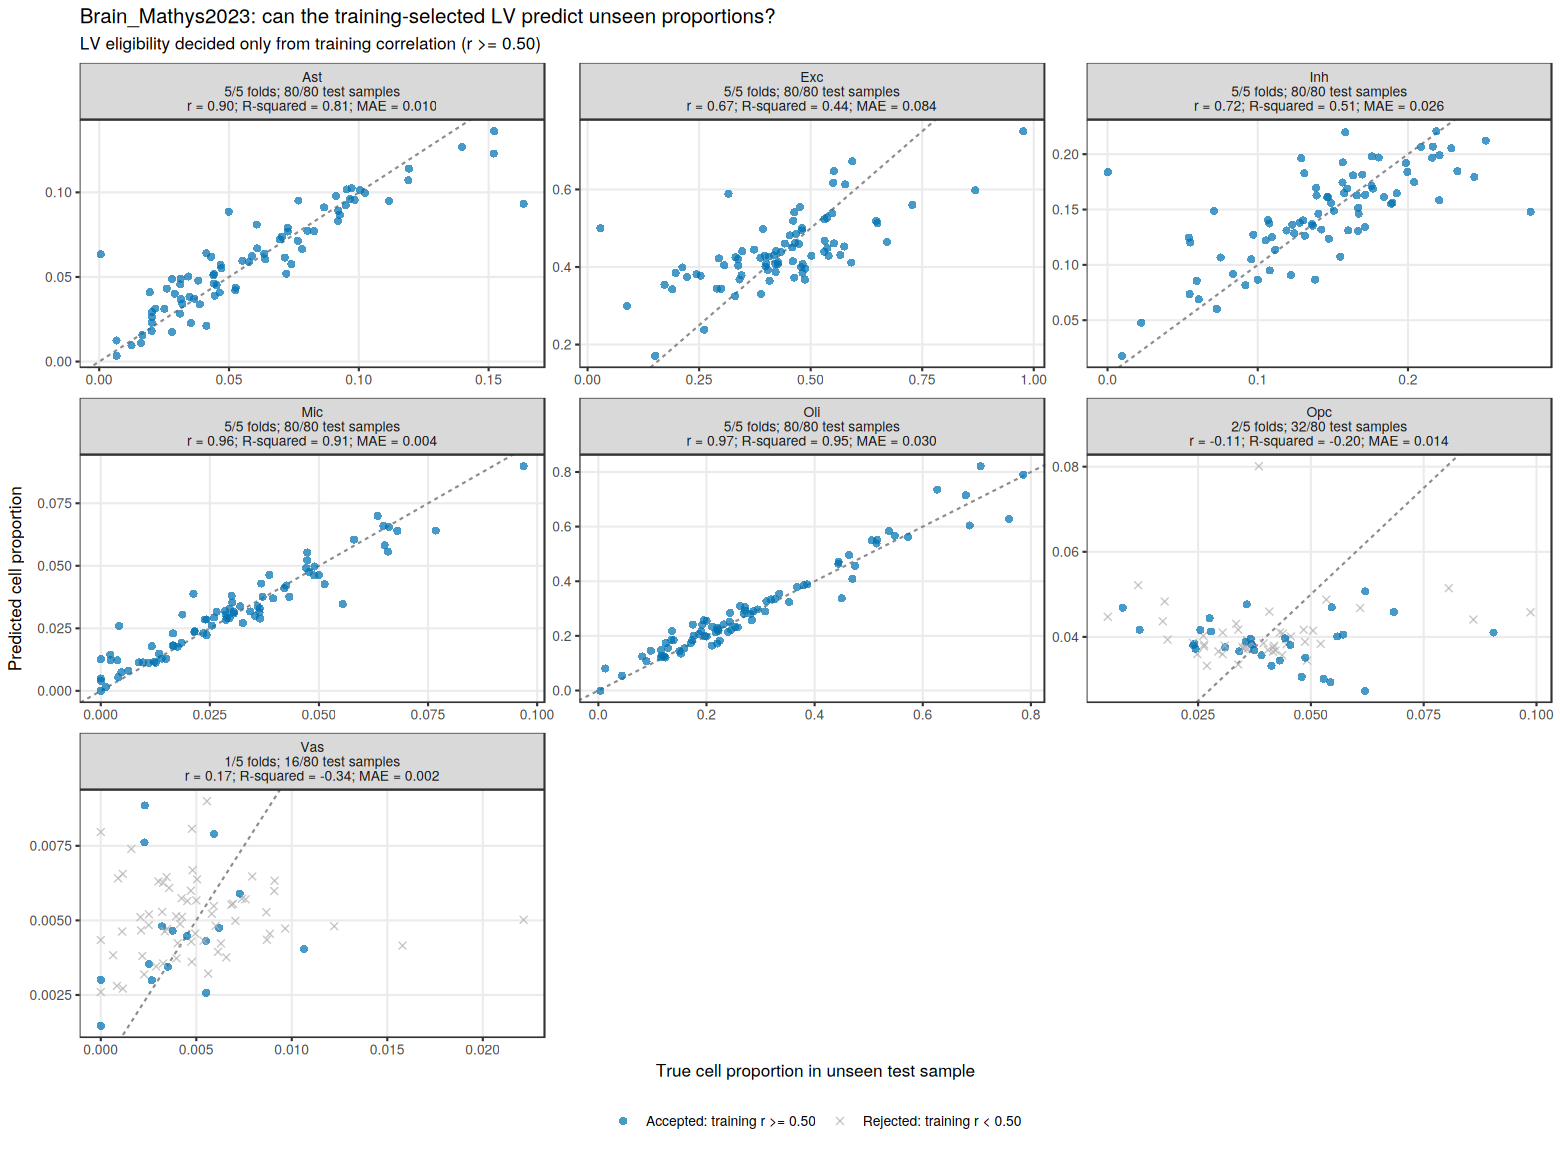

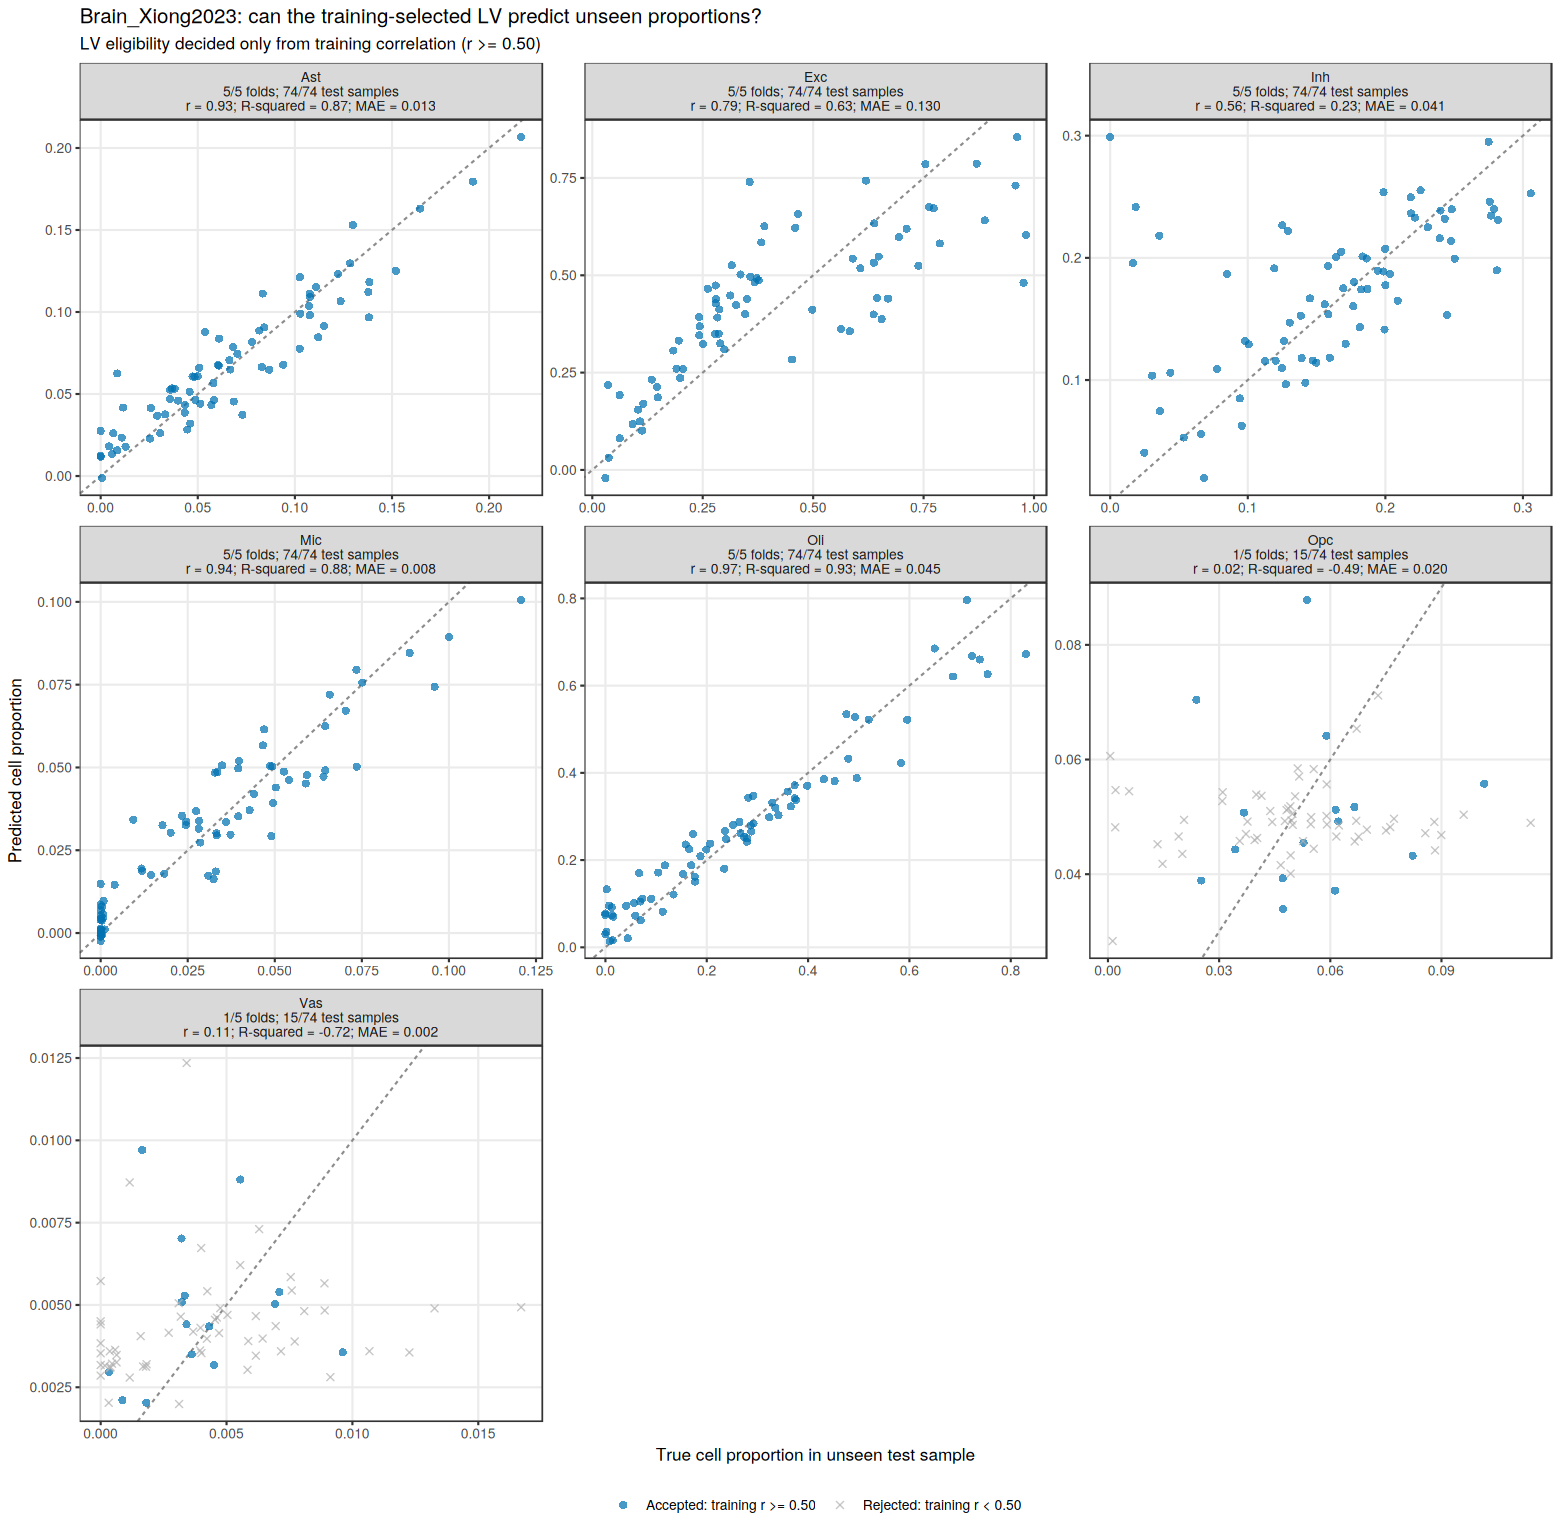

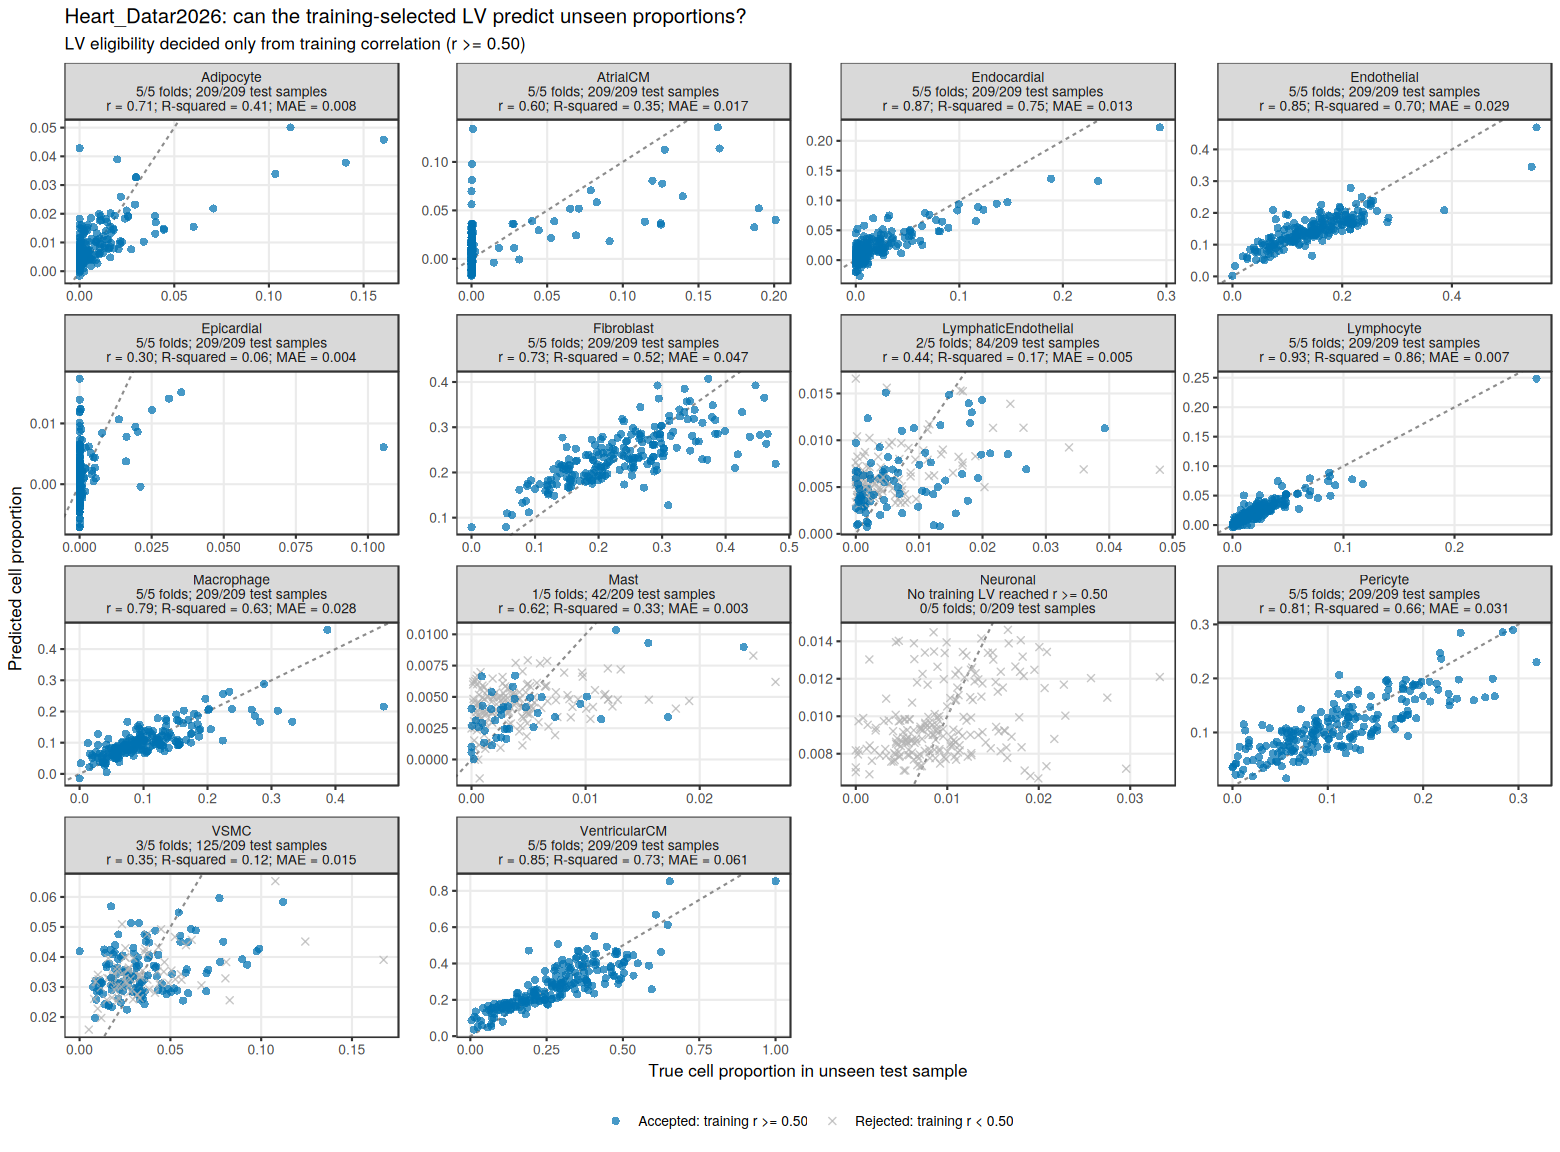

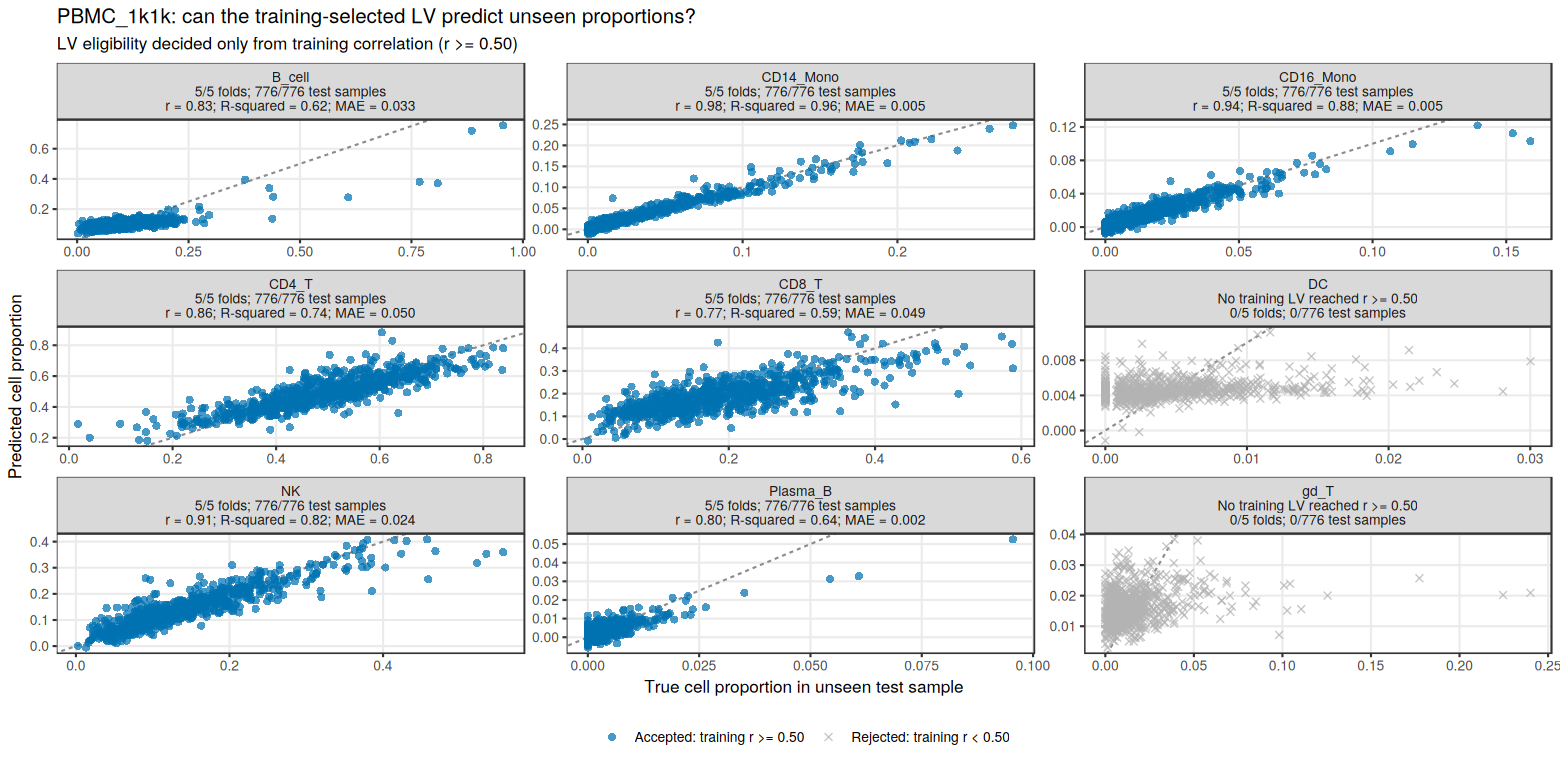

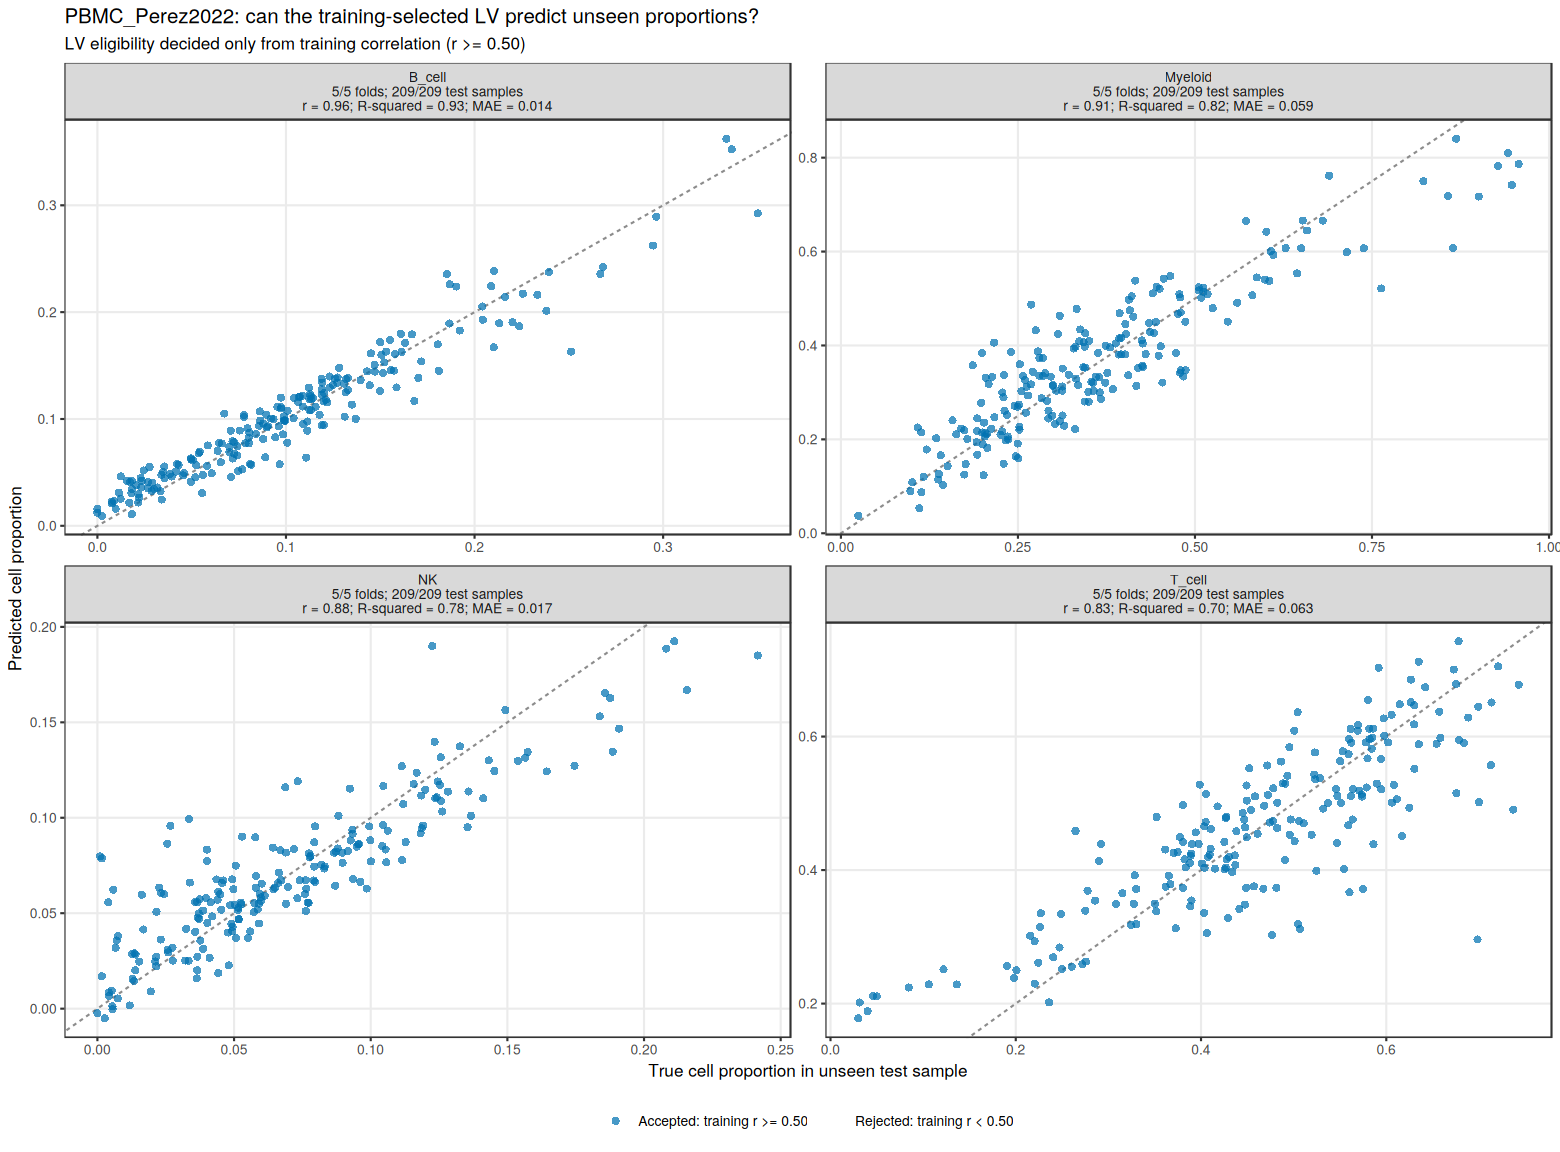

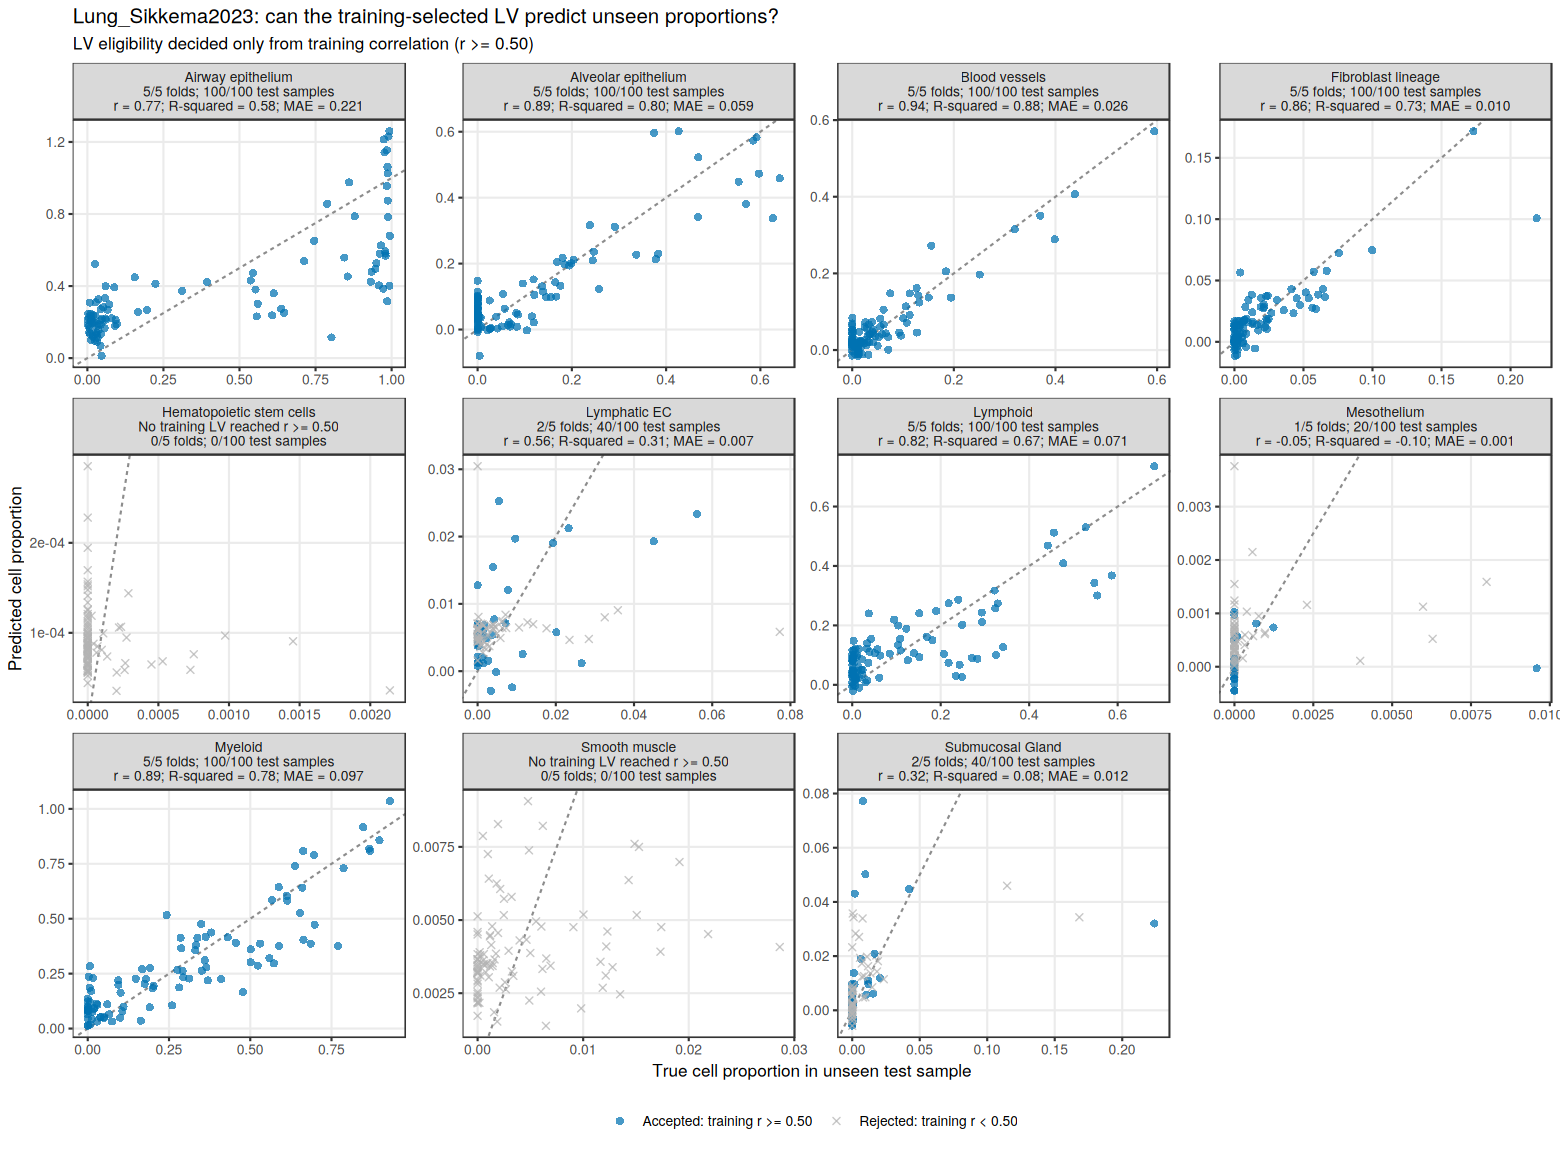

In [3]:
accepted_label <- sprintf('Accepted: training r >= %.2f', MIN_TRAIN_LV_COR)
rejected_label <- sprintf('Rejected: training r < %.2f', MIN_TRAIN_LV_COR)

thresholded_metrics[, panel_label := fifelse(
  n_eligible_folds == 0L,
  sprintf(
    '%s\nNo training LV reached r >= %.2f\n0/%d folds; 0/%d test samples',
    cell_type, min_train_lv_cor, n_total_folds, n_total_test
  ),
  sprintf(
    '%s\n%d/%d folds; %d/%d test samples\nr = %.2f; R-squared = %.2f; MAE = %.3f',
    cell_type, n_eligible_folds, n_total_folds, n_eligible_test, n_total_test,
    pearson_r, predictive_r2, mae
  )
)]

plot_data <- merge(
  predictions,
  thresholded_metrics[, .(dataset, method, cell_type, panel_label)],
  by = c('dataset', 'method', 'cell_type'),
  all.x = TRUE
)
plot_data[, prediction_status := factor(
  fifelse(eligible_train_signal, accepted_label, rejected_label),
  levels = c(accepted_label, rejected_label)
)]

make_test_prediction_plot <- function(dataset_name) {
  dataset_predictions <- plot_data[dataset == dataset_name]
  dataset_panels <- thresholded_metrics[dataset == dataset_name][order(cell_type), panel_label]
  dataset_predictions[, panel_label := factor(panel_label, levels = dataset_panels)]
  n_panels <- uniqueN(dataset_predictions$panel_label)
  n_columns <- min(4L, max(1L, ceiling(sqrt(n_panels))))
  n_rows <- ceiling(n_panels / n_columns)
  options(repr.plot.width = 13, repr.plot.height = max(4.5, 3.2 * n_rows))

  ggplot(
    dataset_predictions,
    aes(x = observed, y = predicted, color = prediction_status, shape = prediction_status)
  ) +
    geom_abline(slope = 1, intercept = 0, color = 'grey55', linetype = 'dashed') +
    geom_point(alpha = 0.72, size = 1.7) +
    facet_wrap(~panel_label, scales = 'free', ncol = n_columns) +
    scale_color_manual(
      values = setNames(c(CLAMP_COLOR, 'grey70'), c(accepted_label, rejected_label)),
      drop = FALSE
    ) +
    scale_shape_manual(
      values = setNames(c(16, 4), c(accepted_label, rejected_label)),
      drop = FALSE
    ) +
    labs(
      x = 'True cell proportion in unseen test sample',
      y = 'Predicted cell proportion',
      color = NULL,
      shape = NULL,
      title = paste0(dataset_name, ': can the training-selected LV predict unseen proportions?'),
      subtitle = sprintf('LV eligibility decided only from training correlation (r >= %.2f)', MIN_TRAIN_LV_COR)
    ) +
    theme_bw(base_size = 10) +
    theme(
      panel.grid.minor = element_blank(),
      strip.text = element_text(size = 8),
      legend.position = 'bottom'
    )
}

for (dataset_name in DATASETS) {
  print(make_test_prediction_plot(dataset_name))
}


## Interpretation

The threshold separates two questions:

1. **Did training find a usable cell-type LV?** This is answered by coverage under the training-only `r >= 0.5` rule.
2. **When it did, were unseen proportions predicted accurately?** This is answered by the test prediction R-squared, Pearson correlation, and MAE.

A low training correlation is therefore not removed or repaired. It is reported as the model being unable to identify a credible single-LV predictor for that fold. Because the 0.5 cutoff was chosen after exploring these data, this thresholded analysis is exploratory and the cutoff should remain fixed for future validation data.
